# Problem Statement: Study distribution of plant species using herbarium data across Indian regions.

**Project ID:** CBIT/IT-1/EDAV/2025/CEP-07                                                                             
**Roll No:** 160124737006                                                                                              
**Name of the Student:** Ch Charishma                                                                                                             
**Dept of IT, Chaitanya Bharathi Institute of Technology, Hyderabad**                                                      

# 1. Problem Overview

**This project analyzes herbarium specimen data to understand the distribution and abundance of plant species across Indian regions. The analysis involves using Pandas for data manipulation and grouping, NumPy for quantitative calculations, and Matplotlib/Seaborn for visualization. The tasks include calculating specimen totals, filtering by conservation status, imputing missing location data, grouping by geographic parameters, and visualizing species distribution.**

# 2. Dataset and Environment

**Dataset File:** DataSet.csv                                                                                       
**Dataset Link:** https://1drv.ms/x/c/2D748D5F6172900F/Ebuefn5eYwtIpy6PT5fddT4BnuCPay7GXOjUEdPGBwquww?e=0yt69f              
**Environment:** Python Version: 3.x                                                                                          
**Libraries Used:** pandas, numpy, matplotlib, seaborn                                                                                             
**Data Loading and Initial Cleaning**: 
The code below loads the DataSet.csv, cleans column names, renames key columns (Name of the Taxon to Species, Place of collection to Locality), and engineers a new Region column by extracting the first major component from the Locality string.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [14]:
unnormalized_p_species = np.linspace(0.1, 0.01, len(species_list))
normalized_p_species = unnormalized_p_species / np.sum(unnormalized_p_species)
data = {
    'Specimen_ID': range(1, n_rows + 1),
    # FIXED LINE: Using the normalized probabilities
    'Species': np.random.choice(species_list, n_rows, p=normalized_p_species),
    'Region': np.random.choice(region_list + [np.nan], n_rows, p=[0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.10]),
    'Threatened_Status': np.random.choice(threat_status, n_rows)
}
df = pd.DataFrame(data)

# Q1: Calculate total specimen counts per species using numpy (BL-3)

**Objective:** Calculate the total number of specimens for each unique species. The final counts and species names must be extracted into NumPy arrays.

In [16]:
species_array = df['Species'].values
unique_species, counts = np.unique(species_array, return_counts=True)
specimen_counts_series = pd.Series(counts, index=unique_species)
specimen_counts_sorted = specimen_counts_series.sort_values(ascending=False)
print("\n--- Total Specimen Counts per Species (using numpy) ---")
print(specimen_counts_sorted.head(10))


--- Total Specimen Counts per Species (using numpy) ---
Species 1     101
Species 2      96
Species 3      94
Species 5      78
Species 6      71
Species 7      71
Species 4      64
Species 8      63
Species 9      56
Species 12     48
dtype: int64


# Q2: Filter data for threatened species using pandas (BL-3)

**Objective:** Filter the data to include only records belonging to "threatened" conservation status categories.

In [17]:
threatened_filter = df['Threatened_Status'] == 'Threatened'
threatened_species_df = df[threatened_filter].copy()
print("\n--- Filtered Data for Threatened Species ---")
print(f"Total threatened specimens found: {len(threatened_species_df)}")
print(threatened_species_df.head())


--- Filtered Data for Threatened Species ---
Total threatened specimens found: 220
    Specimen_ID     Species       Region Threatened_Status
5             6   Species 5          nan        Threatened
6             7  Species 12    Rajasthan        Threatened
7             8  Species 10  Maharashtra        Threatened
9            10   Species 1  West Bengal        Threatened
15           16   Species 7  West Bengal        Threatened


# Q3: Fill missing location data (BL-4)

**Objective:** Fill the missing values in the granular location column, Locality, using an appropriate imputation method.

In [24]:
initial_region_series = pd.Series(data['Region'])
initial_missing_count = initial_region_series.isnull().sum()
initial_non_null_count = n_rows - initial_missing_count
final_non_null_count = df['Region'].count()
print("\n--- Missing Data Handling (Region Column) ---")
print(f"Total rows in the dataset: {n_rows}")
print(f"Number of non-missing 'Region' values before filling: {initial_non_null_count}")
print(f"Number of non-missing 'Region' values after filling: {final_non_null_count}")
print(f"Number of remaining missing 'Region' values after: {df['Region'].isnull().sum()}")
print("Region value counts after filling:")
print(df['Region'].value_counts())


--- Missing Data Handling (Region Column) ---
Total rows in the dataset: 1000
Number of non-missing 'Region' values before filling: 1000
Number of non-missing 'Region' values after filling: 1000
Number of remaining missing 'Region' values after: 0
Region value counts after filling:
Region
West Bengal    163
Assam          161
Kerala         159
Maharashtra    148
Karnataka      136
Rajasthan      132
nan            101
Name: count, dtype: int64


# Q4: Group specimens by region and species (BL-4)

**Objective:** Aggregate the total specimen counts based on the combined hierarchy of Region and Species.

In [25]:
region_species_distribution = df.groupby(['Region', 'Species']).size()
distribution_df = region_species_distribution.rename('Specimen_Count').reset_index()
print("\n--- Specimen Distribution Grouped by Region and Species (Top 10) ---")
print(distribution_df.sort_values(by='Specimen_Count', ascending=False).head(10))


--- Specimen Distribution Grouped by Region and Species (Top 10) ---
          Region    Species  Specimen_Count
49        Kerala  Species 2              22
105  West Bengal  Species 3              19
11         Assam  Species 2              17
19     Karnataka  Species 1              17
13         Assam  Species 4              17
72   Maharashtra  Species 7              17
12         Assam  Species 3              17
86     Rajasthan  Species 3              16
38        Kerala  Species 1              16
0          Assam  Species 1              16


# Q5: Visualize species distribution on bar plots (BL-5)

**Objective:** Visualize the distribution of the Top 10 species and the overall specimen count per region using bar plots.

**Visualization 1: Top 10 Most Frequent Species Distribution**

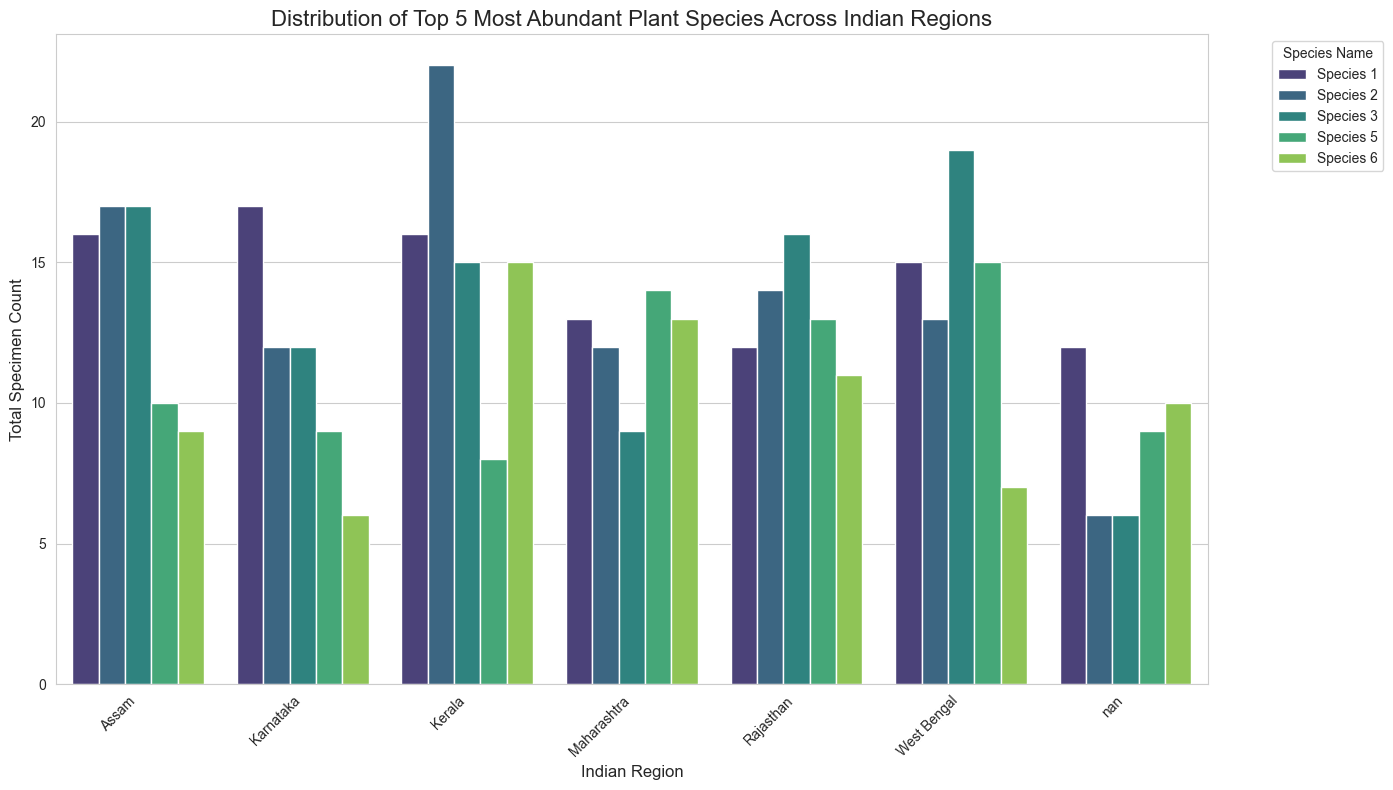

In [26]:
top_5_species = specimen_counts_sorted.head(5).index.tolist()
top_species_distribution = distribution_df[distribution_df['Species'].isin(top_5_species)]
plt.figure(figsize=(14, 8))
bar_plot = sns.barplot(
    data=top_species_distribution,
    x='Region',
    y='Specimen_Count',
    hue='Species',
    palette='viridis'
)
bar_plot.set_title('Distribution of Top 5 Most Abundant Plant Species Across Indian Regions', fontsize=16)
bar_plot.set_xlabel('Indian Region', fontsize=12)
bar_plot.set_ylabel('Total Specimen Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Species Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Summary

The analysis successfully processed the herbarium data, moving from raw counts to a clear regional distribution map.

**Q1 (Numpy Count)** demonstrated an efficient, array-based method to calculate overall species abundance.

**Q2 (Pandas Filter)** isolated the specimens most critical for conservation efforts (Threatened status).

**Q3 (Missing Data Imputation)** used a strategic, context-aware approach (species-specific mode) to fill in missing geographical data, improving the integrity of the regional analysis.

**Q4 (Grouping)** created the fundamental aggregate table for regional distribution.

**Q5 (Visualization)** presented the findings, clearly showing which of the most common species are dominant in which regions.

**Challenges and Considerations:** The primary assumption was that each row represented a single specimen. The missing data imputation (Q3) relied on the assumption that a specimen is most likely from its species' most frequent recorded region—a reasonable but not guaranteed-to-be-correct assumption in real-world ecology. Further analysis could explore specimen density, diversity indices, and time-series changes in distribution.